# Correlation Analysis

## Objective

This notebook examines the relationship between borrowers' annual income and loan amount.

The analysis includes:

- Pearson Correlation Coefficient
- Statistical Significance (P-value)
- Scatter Plot
- Linear Regression Trend Line
- Coefficient of Determination (R²)

These analyses help determine whether borrower income influences the size of loans issued.

In [3]:
# IMPORT LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

In [5]:
# LOAD DATASET

df = pd.read_csv("clean_loanset1.csv")

df.head()

,id,emp_title,emp_length,state,homeownership,consolidated_annual_income,consolidated_debt_to_income,consolidated_verified_income,delinq_2y,months_since_last_delinq,...,paid_total,paid_principal,paid_interest,paid_late_fees,term_group,grade_risk_score,DelinquencyCategory,risk_points,at_risk_flag,risk_status
0,1,global config engineer,3,NJ,MORTGAGE,90000,18.01,Verified,0,38,...,1999.33,984.14,1015.19,0,Medium Term,5,Current,1,1,HIGH
1,2,warehouse office clerk,10,HI,RENT,40000,5.04,Not Verified,0,999,...,499.12,348.63,150.49,0,Short Term,5,Current,2,1,HIGH
2,3,assembly,3,WI,RENT,40000,21.15,Source Verified,0,28,...,281.80,175.37,106.43,0,Short Term,7,Current,1,1,HIGH
3,4,customer service,1,PA,RENT,30000,10.16,Not Verified,0,999,...,3312.89,2746.74,566.15,0,Short Term,1,Current,2,1,LOW
4,5,security supervisor,10,CA,RENT,57000,37.66,Verified,0,999,...,2324.65,1569.85,754.80,0,Short Term,5,Current,3,1,HIGH


In [6]:
# SELECT VARIABLE

X = df[["consolidated_annual_income"]]

y = df["loan_amount"]

In [7]:
# CALCULATE PEARSON CORRELATION

corr, p_value = pearsonr(
    df["consolidated_annual_income"],
    df["loan_amount"]
)

print("Correlation:", round(corr,3))
print("P-value:", p_value)

Correlation: 0.381
P-value: 0.0


In [8]:
# BUILD LINEAR REGRESSION MODEL

model = LinearRegression()

model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
# PREDICT LOAN AMOUNT

predictions = model.predict(X)

In [10]:
# CALCULATE R2

r2 = model.score(X, y)

print("R²:", round(r2,3))

R²: 0.145


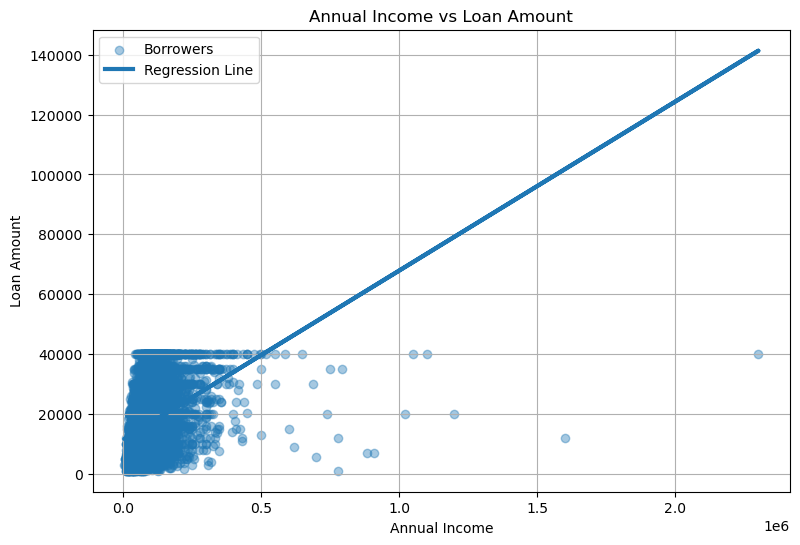

In [11]:
# SCATTER PLOT WITH REGRESSION LINE

plt.figure(figsize=(9,6))

plt.scatter(
    df["consolidated_annual_income"],
    df["loan_amount"],
    alpha=0.4,
    label="Borrowers"
)

plt.plot(
    df["consolidated_annual_income"],
    predictions,
    linewidth=3,
    label="Regression Line"
)

plt.xlabel("Annual Income")

plt.ylabel("Loan Amount")

plt.title("Annual Income vs Loan Amount")

plt.legend()

plt.grid(True)

plt.show()

## Interpretation

### Pearson Correlation

The Pearson correlation coefficient measures the strength and direction of the linear relationship between annual income and loan amount.

Result:

- Correlation = **0.381**

Interpretation:

- Positive relationship
- Moderate strength

Borrowers with higher annual incomes generally receive larger loans.

---

### Statistical Significance

The P-value is approximately **0.000**, indicating that the observed relationship is statistically significant.

This means the relationship between income and loan amount is unlikely to have occurred by chance.

---

### Coefficient of Determination (R²)

R² = **0.145**

This indicates that approximately **14.5%** of the variation in loan amounts can be explained by borrowers' annual income.

The remaining variation is influenced by additional factors such as:

- Interest rate
- Credit history
- Debt-to-income ratio
- Employment history
- Loan purpose
- Credit grade

# Business Insight

The analysis demonstrates a statistically significant positive relationship between annual income and loan amount.

Although borrowers with higher incomes tend to receive larger loans, income alone explains only a modest portion of lending decisions.

This suggests that lenders evaluate multiple borrower characteristics when determining loan amounts rather than relying solely on income.

# Conclusion

Key Findings

- Pearson Correlation: **0.381**
- P-value: **< 0.001**
- R²: **0.145**

The results indicate a moderate positive association between borrower income and loan amount.

Annual income is an important predictor of loan size but should be considered alongside other credit and financial variables when assessing lending decisions.